# Implementing New Sources of NSB

This tutorial shows how to add a **new night-sky-background source** to `nsb2`. You will learn:

1. The `Source` abstraction and the `SourceField` it produces.
2. How a source's brightness and spectrum are represented (`SpectralGrid`).
3. The quickest route: a diffuse source with `LonLatSource` and plain Python functions.
4. A moving body with `EphemerisSource`, and point sources with `CatalogSource`.
5. Writing a fully custom source by subclassing `RadianceSource`.

The examples are self-contained and use a small synthetic telescope so everything runs in seconds without downloads.

In [1]:
import astropy.units as u
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, SkyOffsetFrame
from astropy.time import Time

from nsb2.atmosphere import SingleScatteringAtmosphere
from nsb2.core.dtypes import SourceField
from nsb2.core.instrument import EffectiveApertureInstrument
from nsb2.core.lightpath import DirectPath, ScatteredPath
from nsb2.core.pipeline import Pipeline
from nsb2.core.sources import EphemerisSource, LonLatSource, RadianceSource
from nsb2.core.spectral import Bandpass, SpectralGrid

## 1. The `Source` contract

Every NSB emitter is a `Source`. The pipeline queries a source in two ways:

| Method | Called by | Returns |
| --- | --- | --- |
| `query_direct(observation, pixel_coords, pixel_radii)` | `DirectPath` | `(SourceField, PixelRefs)` — light travelling straight into the pixels. |
| `query_scattered(observation, nside=64)` | `ScatteredPath` | `SourceField` — the whole visible hemisphere, later scattered by the atmosphere. |
| `spectral_grid` (property) | pipeline compilation | the `SpectralGrid` backing the source. |

Both queries return a **`SourceField`**: a bundle of sky positions, brightness `weights`, `spectral_data` indices, and the shared `spectral_grid`. A `radiance_field=True` flag marks *diffuse* sources (surface brightness per solid angle) as opposed to discrete point sources.

You rarely implement `Source` from scratch. Instead you reuse one of the building blocks:

- **`LonLatSource`** — a diffuse field described by functions of longitude/latitude (airglow, zodiacal light, light pollution).
- **`EphemerisSource`** — a solar-system body with a time-dependent position (Moon, planets).
- **`CatalogSource`** / **`HEALPixSource`** — point-source catalogs and pre-binned sky maps (stars).
- **`RadianceSource`** — a base class to subclass for fully custom diffuse behaviour.

## 2. Describing brightness and spectrum: `SpectralGrid`

A `SpectralGrid` stores the spectral shape of a source and is callable on *data coordinates*. It is built from three things:

```python
SpectralGrid(points, wvl, flx)
```

- `points`: a list of parameter axes (e.g. a colour index or phase angle). Use `[]` for a single fixed spectrum.
- `wvl`: the wavelength grid (a `Quantity`).
- `flx`: the flux array. With no parameters its shape is `(W, C)` — `W` wavelengths and `C` spectral *components* (the min/med/max realisations that flow through to the last prediction axis).

For a diffuse (radiance) source the flux carries a *per-solid-angle* unit. Below we build a warm, sodium-lamp-like continuum with a single component.

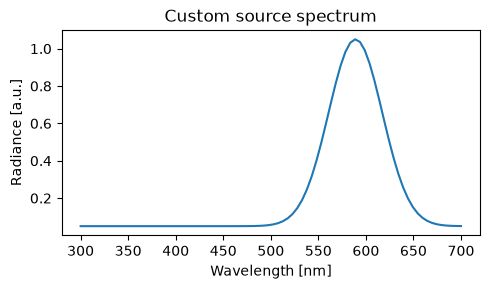

In [2]:
wvl = np.linspace(300, 700, 80) * u.nm
sed = np.exp(-(((wvl.value - 589) / 40) ** 2)) + 0.05  # sodium bump + faint continuum

# Radiance flux: photons / s / m^2 / micron / arcsec^2, one component -> shape (W, 1)
flx = np.atleast_2d(sed).T / u.s / u.m**2 / u.micron / u.arcsec**2
spectral_grid = SpectralGrid([], wvl, flx)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(wvl, spectral_grid.flx[:, 0])
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Radiance [a.u.]")
ax.set_title("Custom source spectrum")
fig.tight_layout()

## 3. A synthetic telescope and atmosphere

So we can actually *run* our new sources, we set up a tiny synthetic camera, a minimal atmosphere, and an observation. (See the *Adding a Custom Telescope* tutorial for the details of the response format.)

In [3]:
def build_synthetic_response(n_side=4, fov_deg=2.0, grid=11, peak_area_m2=400.0):
    centres = np.linspace(-fov_deg / 2, fov_deg / 2, n_side)
    cx, cy = (a.ravel() for a in np.meshgrid(centres, centres))
    half = np.deg2rad(fov_deg / (n_side - 1)) / 2 * 1.5
    x_arr, y_arr, v_arr = [], [], []
    for x0_deg, y0_deg in zip(cx, cy):
        x0, y0 = np.deg2rad(x0_deg), np.deg2rad(y0_deg)
        x = np.linspace(x0 - half, x0 + half, grid)
        y = np.linspace(y0 - half, y0 + half, grid)
        sigma = half * 0.4
        gx = np.exp(-((x - x0) ** 2) / (2 * sigma**2))
        gy = np.exp(-((y - y0) ** 2) / (2 * sigma**2))
        v_arr.append(peak_area_m2 * np.outer(gx, gy))
        x_arr.append(x)
        y_arr.append(y)
    return {"x": np.array(x_arr), "y": np.array(y_arr), "values": np.array(v_arr)}


bandpass = Bandpass(wvl, np.exp(-(((wvl.value - 450) / 90) ** 2)))
telescope = EffectiveApertureInstrument(build_synthetic_response(), bandpass)


def airmass(Z):
    return 1 / np.cos(np.clip(Z, 0, np.deg2rad(85)))


atmosphere = SingleScatteringAtmosphere(
    airmass,
    tau_rayleigh=lambda lam: 0.01 * np.ones(lam.shape),
    tau_mie=lambda lam: 0.005 * np.ones(lam.shape),
    tau_absorption=lambda lam: np.zeros(lam.shape),
    g=0.8,
)

location = EarthLocation.from_geodetic(16.5, -23.27, 1.8 * u.km)
base = AltAz(obstime=Time("2024-06-15T23:00:00"), location=location)
# Point low toward the north so a horizon light-dome is in the field of view
target = SkyCoord(alt=20 * u.deg, az=0 * u.deg, frame=base)
observation = SkyOffsetFrame(origin=target, rotation=0 * u.deg)

## 4. The quick route: a diffuse source with `LonLatSource`

`LonLatSource` turns two plain functions into a full diffuse source, so you never touch the `Source` machinery directly:

- `weight_function(lon, lat)` → a `(N,)` `Quantity` of brightness weights (the amplitude multiplying the spectrum).
- `data_function(lon, lat)` → an `(N, D)` array of indices into the spectral grid's parameter axes (`D = 0` when the grid has no parameters).

`lon` and `lat` arrive in **radians**, expressed in the source's `frame`. Passing `frame=None` means "work directly in the observation's local horizontal frame", so `lat` is the altitude and `lon` an azimuth-like angle.

We model an **artificial light dome** from a city to the north: bright near the horizon and peaked toward one azimuth.

In [4]:
def weight_function(lon, lat):
    altitude = lat  # radians; frame=None -> lat is altitude
    horizon = np.exp(-altitude / np.deg2rad(15))  # brightest near the horizon
    azimuth = np.exp(-(np.sin(lon / 2) ** 2) / 0.05)  # peaked toward lon = 0 (north)
    return np.clip(horizon * azimuth, 0, None) * u.dimensionless_unscaled


def data_function(lon, lat):
    return np.empty((len(lat), 0))  # no spectral parameters -> D = 0


light_dome = LonLatSource(None, weight_function, data_function, spectral_grid, name="CityLightDome")

In [5]:
model = Pipeline(telescope, atmosphere, [light_dome], paths=[DirectPath(), ScatteredPath(nside=16)])
predictions = model.predict(observation)

for p in predictions:
    med = p.rates.to(u.MHz)[:, 1]
    print(f"{p.source_name:16s} | {p.path_name:14s} | median {med.mean().value:.4g} MHz")

CityLightDome    | DirectPath     | median 5.367 MHz
CityLightDome    | ScatteredPath  | median 0.06037 MHz


We can inspect the raw brightness pattern the source produces over the sky to confirm it behaves as intended (a dome hugging the northern horizon):

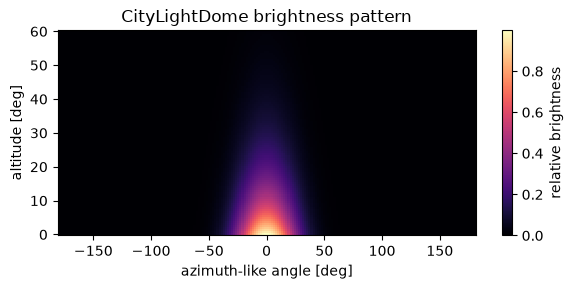

In [6]:
az = np.deg2rad(np.linspace(-180, 180, 200))
alt = np.deg2rad(np.linspace(0, 60, 100))
AZ, ALT = np.meshgrid(az, alt)
brightness = weight_function(AZ.ravel(), ALT.ravel()).value.reshape(AZ.shape)

fig, ax = plt.subplots(figsize=(6, 3))
pc = ax.pcolormesh(np.rad2deg(AZ), np.rad2deg(ALT), brightness, shading="auto", cmap="magma")
fig.colorbar(pc, ax=ax, label="relative brightness")
ax.set_xlabel("azimuth-like angle [deg]")
ax.set_ylabel("altitude [deg]")
ax.set_title("CityLightDome brightness pattern")
fig.tight_layout()

## 5. A moving body with `EphemerisSource`

For a solar-system body, `EphemerisSource` handles the time-dependent position via astropy's `get_body`. You provide:

- the body name (anything `astropy.coordinates.get_body` understands, e.g. `"jupiter"`),
- `weight_function(obstime)` → brightness weight(s),
- `data_function(obstime)` → spectral index/indices,
- the `SpectralGrid`.

The source automatically drops the body when it is below the horizon. Here is a toy "bright planet" (see `nsb2.emitter.moon.from_noll2013` for a physically complete example).

In [ ]:
# A planet is a *point* source, so its spectrum is a flux (per area), not a
# radiance (per solid angle): photons / s / m^2 / nm, with a single component.
# Approximate Jupiter as a solar reflector: Planck function at T_sun in photon-count units.
h, c, k = 6.626e-34, 3e8, 1.381e-23
T_sun = 5778.0
lam_m = wvl.to(u.m).value
solar_sed = lam_m**-4 / (np.exp(h * c / (lam_m * k * T_sun)) - 1)
solar_sed /= solar_sed.max()

planet_flx = np.atleast_2d(solar_sed).T / u.s / u.m**2 / u.nm
planet_grid = SpectralGrid([], wvl, planet_flx)


def planet_weight(obstime):
    return np.atleast_1d(1.0) * u.dimensionless_unscaled


def planet_data(obstime):
    return np.empty((1, 0))  # no spectral parameters


planet = EphemerisSource("jupiter", planet_weight, planet_data, planet_grid, name="ToyPlanet")

# Whether Jupiter is above the horizon depends on the time/location; the query
# returns an (possibly empty) SourceField either way.
field = planet.query_scattered(observation)
print(f"ToyPlanet sources above horizon: {len(field.coords)}")


ToyPlanet sources above horizon: 0


At the observation time above, Jupiter happens to be below the horizon, so the field is empty. If we instead pick a time when the body has risen, `query_scattered` returns its position and we can plot it on an all-sky map (azimuth around the circle, zenith distance as the radius):

ToyPlanet sources above horizon: 1


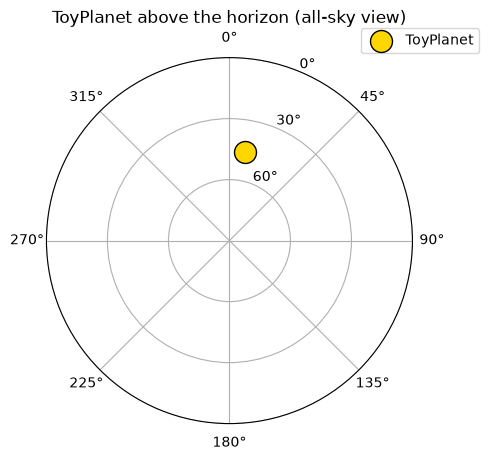

In [8]:
# Pick a time when Jupiter is above the horizon at this site (it culminates near 09:00 UTC)
planet_base = AltAz(obstime=Time("2024-06-15T09:00:00"), location=location)
planet_target = SkyCoord(alt=45 * u.deg, az=10 * u.deg, frame=planet_base)
planet_obs = SkyOffsetFrame(origin=planet_target, rotation=0 * u.deg)

field = planet.query_scattered(planet_obs)
print(f"ToyPlanet sources above horizon: {len(field.coords)}")

# Transform the source position into the local horizontal frame for an all-sky view
planet_altaz = field.coords.transform_to(planet_base)
p_az = planet_altaz.az.to_value(u.rad)
p_zenith = 90 - planet_altaz.alt.to_value(u.deg)  # radius = zenith distance

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")  # azimuth 0 (north) at top
ax.set_theta_direction(-1)  # azimuth increases clockwise (E to the right)
ax.set_rlim(0, 90)  # zenith at centre, horizon at the outer edge
ax.set_rgrids([30, 60, 90], labels=["60°", "30°", "0°"])
ax.scatter(p_az, p_zenith, s=250, c="gold", edgecolor="k", zorder=5, label="ToyPlanet")
ax.set_title("ToyPlanet above the horizon (all-sky view)")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
fig.tight_layout()

### NSB rate the instrument sees from the planet

Position isn't the whole story — we want the **rate the telescope records**. Feed the planet through a `Pipeline` with our synthetic instrument, pointing at the time when Jupiter is up. `predict` returns one `Prediction` per light path, each carrying a per-pixel `rates` array of shape `(N_pixels, 3)` (the min/median/max spectral realisations) in units convertible to `MHz`.

In [9]:
planet_model = Pipeline(
    telescope, atmosphere, [planet], paths=[DirectPath(), ScatteredPath(nside=16)]
)
planet_predictions = planet_model.predict(planet_obs)

for p in planet_predictions:
    med = p.rates.to(u.MHz)[:, 1]
    print(f"{p.source_name:16s} | {p.path_name:14s} | median {med.mean().value:.4g} MHz")

ToyPlanet        | DirectPath     | median 0.0001712 MHz
ToyPlanet        | ScatteredPath  | median 1.268e-08 MHz


### Side by side: which source dominates?

Both sources now have per-pixel NSB rates for the **same instrument**. We summarise each `Prediction` by its median per-pixel rate and compare the `CityLightDome` (from the earlier northern-horizon pointing) against the `ToyPlanet` (from the Jupiter pointing), split by light path:

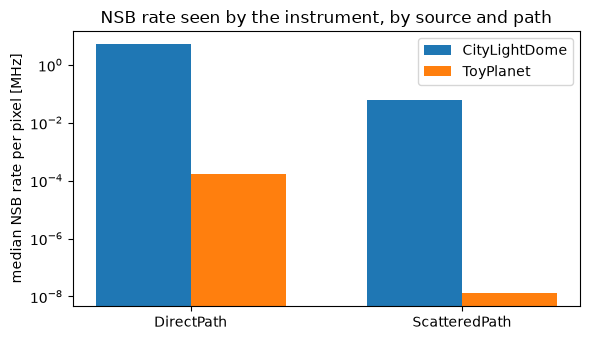

In [10]:
def median_rates_by_path(preds):
    return {p.path_name: p.rates.to(u.MHz)[:, 1].mean().value for p in preds}


dome_rates = median_rates_by_path(predictions)
planet_rates = median_rates_by_path(planet_predictions)

paths = ["DirectPath", "ScatteredPath"]
x = np.arange(len(paths))
w = 0.35

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(x - w / 2, [dome_rates[p] for p in paths], w, label="CityLightDome")
ax.bar(x + w / 2, [planet_rates[p] for p in paths], w, label="ToyPlanet")
ax.set_yscale("log")  # the two sources differ by orders of magnitude
ax.set_xticks(x)
ax.set_xticklabels(paths)
ax.set_ylabel("median NSB rate per pixel [MHz]")
ax.set_title("NSB rate seen by the instrument, by source and path")
ax.legend()
fig.tight_layout()

### Per-pixel camera images

The single-number summaries above hide the spatial structure. Because each `Prediction` carries a rate for *every* pixel, we can reshape those values back onto the camera and view them as 2-D images — one for each source. Summing the light paths gives the total rate the instrument records in each pixel:

Text(0.5, 0.98, 'Per-pixel NSB rate seen by the instrument')

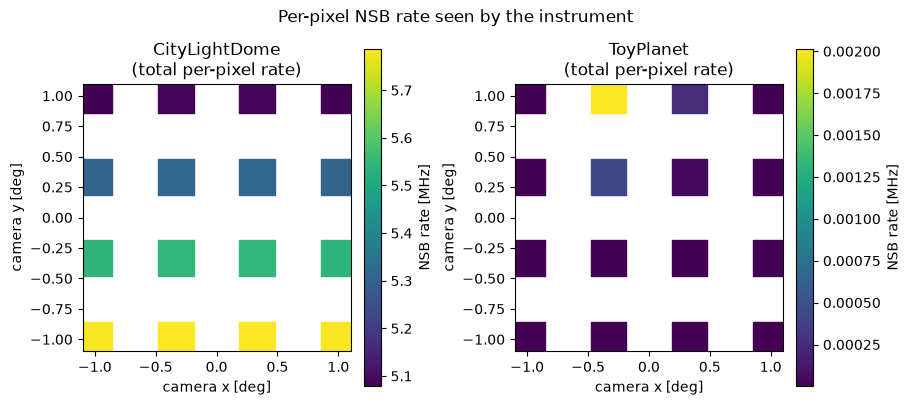

In [11]:
# Per-pixel camera images: total median NSB rate (summed over light paths) for each source.
def camera_rate_per_pixel(preds):
    return sum(p.rates.to(u.MHz)[:, 1].value for p in preds)  # (N_pixels,)


pix = telescope.pixel_coords(observation)
cam_x = pix.lon.to_value(u.deg)
cam_y = pix.lat.to_value(u.deg)

dome_image = camera_rate_per_pixel(predictions)
planet_image = camera_rate_per_pixel(planet_predictions)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
for ax, image, title in zip(axes, [dome_image, planet_image], ["CityLightDome", "ToyPlanet"]):
    # Each source spans a very different scale, so give every panel its own colour range.
    sc = ax.scatter(cam_x, cam_y, c=image, s=650, marker="s", cmap="viridis")
    fig.colorbar(sc, ax=ax, label="NSB rate [MHz]")
    ax.set_aspect("equal")
    ax.set_xlabel("camera x [deg]")
    ax.set_ylabel("camera y [deg]")
    ax.set_title(f"{title}\n(total per-pixel rate)")
fig.suptitle("Per-pixel NSB rate seen by the instrument")

## 6. Full control: subclassing `RadianceSource`

When functions aren't enough — say you carry internal state, read from a data cube, or need custom hemisphere sampling — subclass `RadianceSource`. You only have to implement:

- `_query_coords(coords)` → `(weights, data)` for a batch of `SkyCoord` positions. `RadianceSource` reuses this for the direct path automatically.
- `query_scattered(observation, nside)` → the visible hemisphere as a `SourceField` (usually a HEALPix sampling of the sky above the horizon).

and set the `_spectral_grid` attribute. Below is a self-contained "gradient glow" that fades with altitude.

In [12]:
class GradientGlow(RadianceSource):
    """A diffuse glow whose brightness decays exponentially with altitude."""

    def __init__(self, spectral_grid, scale_deg=30.0, name="GradientGlow"):
        self._spectral_grid = spectral_grid
        self.scale = np.deg2rad(scale_deg)
        self.name = name

    def _query_coords(self, coords):
        altitude = coords.spherical.lat.rad
        weight = np.exp(-altitude / self.scale)
        return (weight * u.dimensionless_unscaled)[:, None], np.empty((len(altitude), 0))

    def query_scattered(self, observation, nside=64):
        lon, lat = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)), lonlat=True)
        lon, lat = lon[lat > 0], lat[lat > 0]  # upper hemisphere only
        coords = SkyCoord(lon, lat, unit="deg", frame=observation.origin)
        weight, data = self._query_coords(coords)
        weight = weight * hp.nside2pixarea(nside) * u.radian**2  # weight by pixel solid angle
        return SourceField(
            coords=coords,
            weights=weight,
            spectral_data=data,
            spectral_grid=self._spectral_grid,
            radiance_field=True,
        )


gradient_glow = GradientGlow(spectral_grid)

In [13]:
model2 = Pipeline(
    telescope, atmosphere, [gradient_glow], paths=[DirectPath(), ScatteredPath(nside=16)]
)
predictions2 = model2.predict(observation)

for p in predictions2:
    med = p.rates.to(u.MHz)[:, 1]
    print(f"{p.source_name:16s} | {p.path_name:14s} | median {med.mean().value:.4g} MHz")

GradientGlow     | DirectPath     | median 10.45 MHz
GradientGlow     | ScatteredPath  | median 0.2426 MHz


## 7. Choosing an approach

| Your source is… | Use |
| --- | --- |
| A diffuse field describable by functions of sky position | `LonLatSource` |
| A moving solar-system body | `EphemerisSource` |
| A catalog of point sources | `CatalogSource` |
| A pre-binned all-sky map | `HEALPixSource` |
| A diffuse field needing custom state or sampling | subclass `RadianceSource` |
| Something totally different (custom point-source logic) | subclass `Source` directly |

To ship your source with the package, add a factory function under `nsb2/emitter/` that returns the configured source — exactly as `airglow.from_eso_skycalc`, `zodiacal.from_leinert1998`, and `moon.from_noll2013` do.